In [25]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import simulate_data as sim
reload(sim)

import elbo
reload(elbo)

<module 'elbo' from '/nfs/scistore17/robingrp/mpieczar/Jupyter/vi_tobit/elbo.py'>

In [42]:
rng= np.random.default_rng(42)

n, d = 1000, 500
l_perc, u_perc = 10, 80
beta_scale = 100
perc_sig = 0.05

X = sim.X_corr_blocks(n, d, k = 20, corr =0.9, seed = 42)
beta_true = sim.beta_sparse(d+1, beta_scale, perc_sig, seed = 42)
y, l ,u = sim.y_tobit(X, l_perc, u_perc, beta_true, seed=42)

mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print("True beta:\n", beta_true[:5])
print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

True beta:
 [ 0. -0.  0.  0. -0.]
Censored low: 100  |  uncensored: 700  |  Censored high: 200


In [46]:
vi_results = elbo.adam_vi(X, y, l, u,
                      pi0=perc_sig,
                      tau2=beta_scale ** 2,
                      n_iter=10_000,
                      lr=0.01,
                      seed=42,
                      n_mc=20)

print("Estimated beta (m):\n", vi_results["m"][:5])
print("Estimated sigma_y2:", vi_results["sigma_y2"])
print("Final ELBO:", vi_results["elbo_history"][-1])

ADAM VI: 100%|██████████| 10000/10000 [00:52<00:00, 191.33it/s]

Estimated beta (m):
 [-1.39400377  1.74562747 -3.67452864 -5.39249448 -1.88274819]
Estimated sigma_y2: 37.1464497738417
Final ELBO: -2292.264070899575


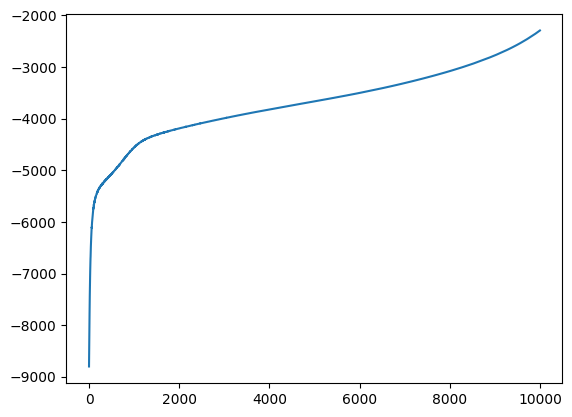

In [51]:
import matplotlib.pyplot as plt

plt.plot(vi_results["elbo_history"])
plt.show()

In [52]:
log_prob

array([-1.24852543e-05, -1.37695932e-05, -1.34437879e-05, -1.38686998e-05,
       -1.38131027e-05, -1.31946441e-05, -1.37811524e-05, -1.43213078e-05,
       -1.39105640e-05, -1.38516527e-05, -1.38139830e-05, -1.36749651e-05,
       -1.36225869e-05, -1.44434772e-05, -1.36810300e-05, -1.40970818e-05,
       -1.36980025e-05, -1.36016062e-05, -1.38845551e-05, -1.40049130e-05,
       -1.37990675e-05, -1.20618707e-05, -1.14877924e-05, -1.20772862e-05,
       -1.23625578e-05, -1.26339938e-05, -1.19743513e-05, -1.22392416e-05,
       -1.21581800e-05, -1.21440967e-05, -1.21495422e-05, -1.18377760e-05,
       -1.21784924e-05, -1.21541255e-05, -1.18689586e-05, -1.22518860e-05,
       -1.20593157e-05, -1.18784649e-05, -1.22308377e-05, -1.19928737e-05,
       -1.21866498e-05, -1.24665049e-05, -1.25385088e-05, -1.24186286e-05,
       -1.29080458e-05, -1.21525119e-05, -1.21745080e-05, -1.24883964e-05,
       -1.25194849e-05, -1.23069307e-05, -1.25754294e-05, -1.22685720e-05,
       -1.23027060e-05, -

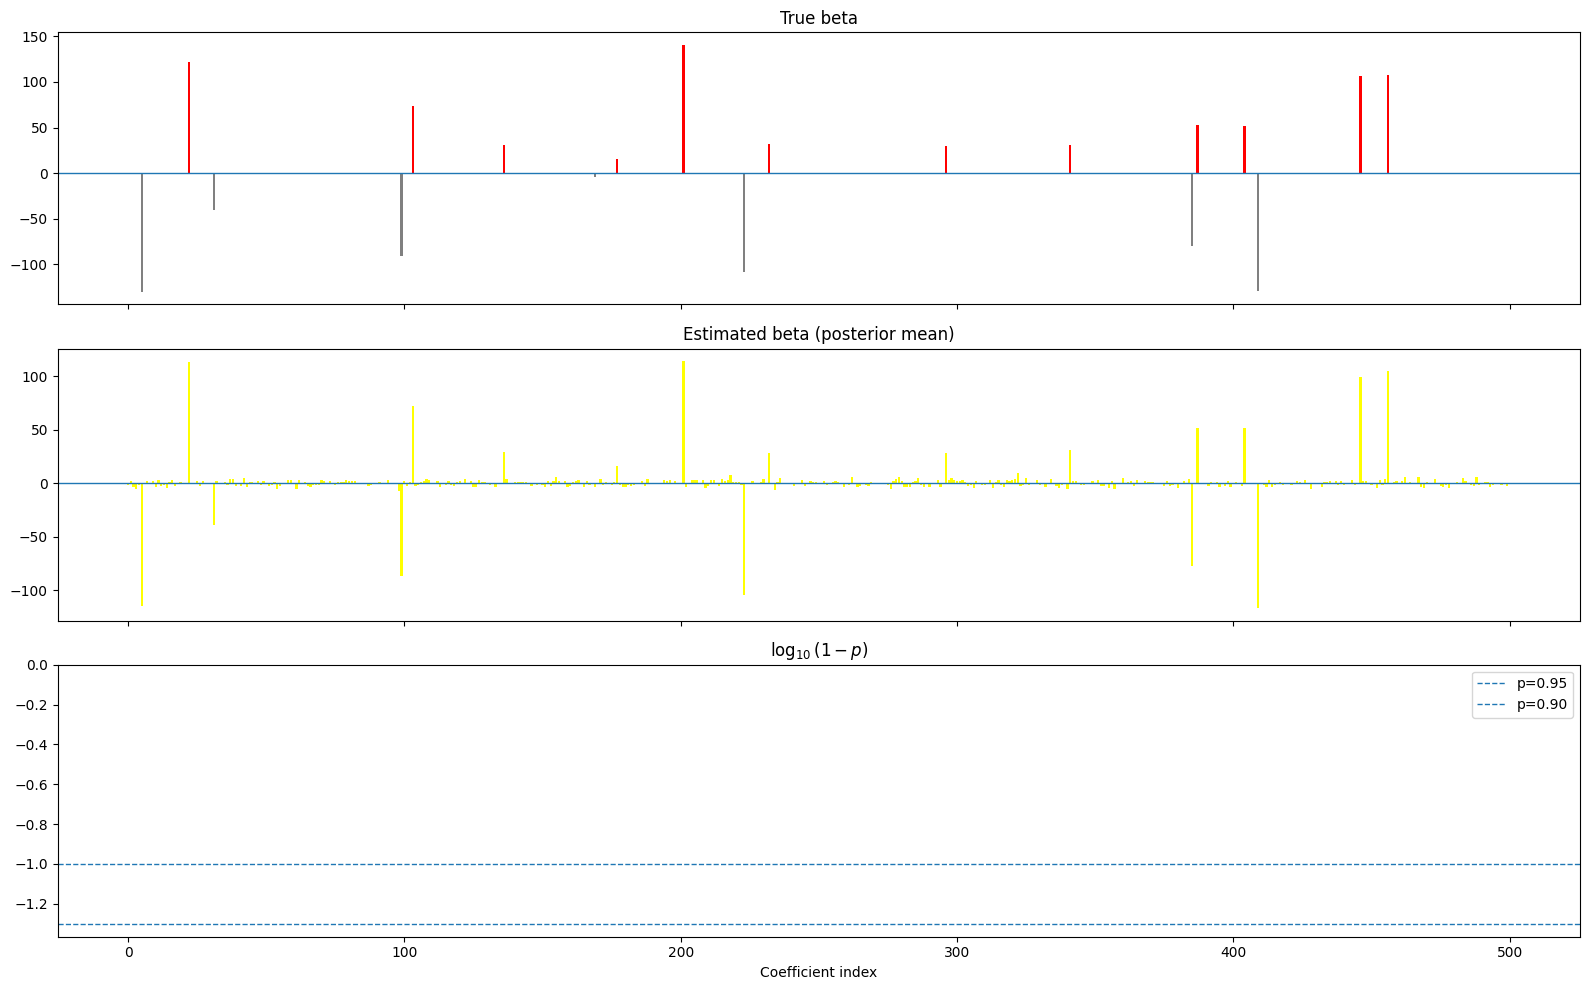

In [55]:
import numpy as np
import matplotlib.pyplot as plt

beta_mean = vi_results["m"]
p_select = vi_results["gamma"]

idx = np.arange(len(beta_true))

fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 10),
    sharex=True
)

# 1) beta true
colors_true = np.where(beta_true > 0, "red", "gray")

axes[0].bar(
    idx,
    beta_true,
    color=colors_true
)

axes[0].axhline(0, linewidth=1)
axes[0].set_title("True beta")


# 2) beta estimated
colors_est = np.where(
    p_select >= 0.95,
    "red",
    np.where(
        p_select >= 0.9,
        "orange",
        "yellow"
    )
)

axes[1].bar(
    idx,
    beta_mean,
    color=colors_est
)

axes[1].axhline(0, linewidth=1)
axes[1].set_title("Estimated beta (posterior mean)")


# 3) log10(1-p)
log_prob = np.log10(1 - p_select + 1e-10)

axes[2].bar(
    idx,
    log_prob,
    color="steelblue"
)

axes[2].set_title(r"$\log_{10}(1-p)$")
axes[2].axhline(
    np.log10(1-0.95),
    linestyle="--",
    linewidth=1,
    label="p=0.95"
)

axes[2].axhline(
    np.log10(1-0.9),
    linestyle="--",
    linewidth=1,
    label="p=0.90"
)

axes[2].legend()

axes[2].set_xlabel("Coefficient index")

plt.tight_layout()
plt.show()